In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [39]:
df=pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [40]:
df.shape

(42000, 785)

In [41]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
import matplotlib.pyplot as plt

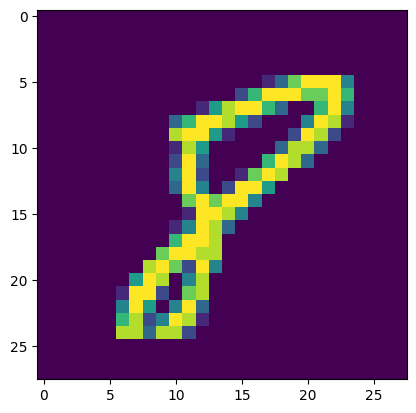

In [43]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

In [44]:
X= df.iloc[:,1:]
y= df.iloc[:,0]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y ,test_size=0.2,random_state=42)

In [45]:
X_train.shape

(33600, 784)

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
KNN = KNeighborsClassifier()

In [48]:
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [49]:
import time
start = time.time()
y_pred = KNN.predict(X_test)
print(time.time()-start)

13.6647367477417


In [50]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

PCS
Step 1  -- Apply standerdization on features 

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [52]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
from sklearn.decomposition import PCA
pca=PCA(n_components=100)

In [54]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf= pca.transform(X_test)

In [55]:
X_train_trf.shape

(33600, 100)

In [56]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)


KNeighborsClassifier()

In [57]:
y_pred=knn.predict(X_test_trf)

In [58]:
accuracy_score(y_test,y_pred)

0.9536904761904762

In [60]:
for i in range (1,784):
    pca=PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf= pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf,y_train)
    y_pred=knn.predict(X_test_trf)
    print(accuracy_score(y_test,y_pred),"on:",i)

0.2573809523809524 on: 1


KeyboardInterrupt: 

In [61]:
pca = PCA(n_components=2)
X_train_trf= pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [62]:
X_train_trf

array([[-2.71861928, -0.49023512],
       [-0.67692615, -6.75326556],
       [-3.03326525,  6.50994588],
       ...,
       [ 2.14883298,  0.7812774 ],
       [ 1.05955719,  0.94753547],
       [17.70260711,  1.96308952]])

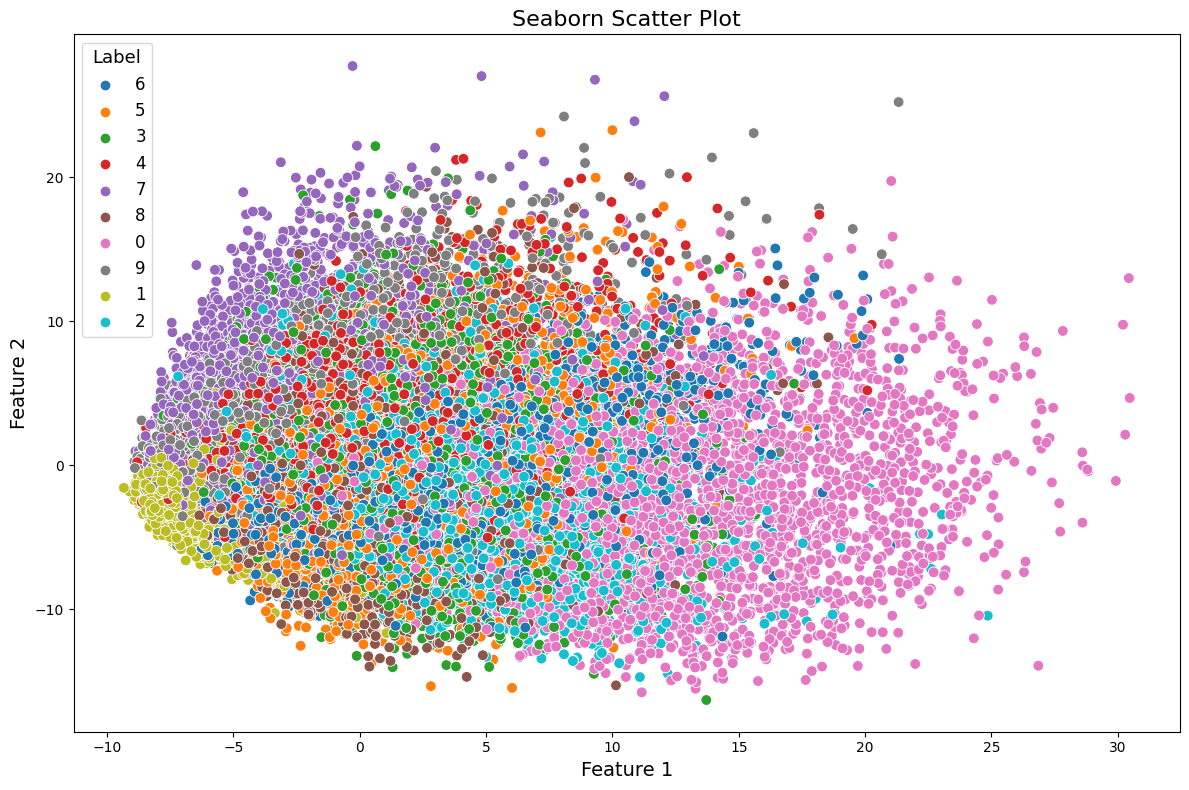

In [66]:

df = pd.DataFrame({
    'x': X_train_trf[:, 0],
    'y': X_train_trf[:, 1],
    'label': y_train.astype(str)
})

# Plot with larger figure size
plt.figure(figsize=(12, 8))  # Increased width and height
sns.scatterplot(data=df, x='x', y='y', hue='label', palette='tab10', s=60)  # Optional: increase marker size with `s`
plt.title('Seaborn Scatter Plot', fontsize=16)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.legend(title='Label', fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.show()

In [68]:
pca = PCA(n_components = 3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [69]:
X_train_trf

array([[-2.71862792, -0.48998928,  1.13485755],
       [-0.67697081, -6.75427108, -2.33558219],
       [-3.0332361 ,  6.5103185 ,  7.49253041],
       ...,
       [ 2.14885153,  0.78063351, -0.74637046],
       [ 1.05957144,  0.94750017,  3.94884532],
       [17.70257589,  1.96184336, -4.94366484]])

In [71]:
import plotly.express as px

df = pd.DataFrame({
    'PC1': X_train_trf[:, 0],
    'PC2': X_train_trf[:, 1],
    'PC3': X_train_trf[:, 2],
    'label': y_train.astype(str)
})

fig = px.scatter_3d(df, x='PC1', y='PC2', z='PC3',
                    color='label',
                    color_discrete_sequence=px.colors.qualitative.G10,
                    title='Interactive 3D PCA Scatter Plot')

fig.update_layout(
    width=900,
    height=700,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend_title='Label'
)

fig.show()

In [72]:
pca.explained_variance_

array([40.67111198, 29.1702339 , 26.74459581])

In [74]:
pca.components_

array([[ 3.97533079e-18,  9.13883428e-19, -4.09924899e-20, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-1.33014095e-17, -8.06401220e-18, -4.96846716e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 1.08596409e-16,  7.49649974e-18, -1.50430018e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])